# API Test Notebook

In [85]:
import json
import ssl
import urllib.parse
import urllib.request

import certifi

params = urllib.parse.urlencode(
    {
        "start": "1",
        "limit": "15",
        "convert": "USD",
    }
)

request = urllib.request.Request(
    f"https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest?{params}",
    headers={
        "Accept": "application/json",
        "X-CMC_PRO_API_KEY": "4383bffec8ae4920a2958e5c5010421e",
    },
)

context = ssl.create_default_context(cafile=certifi.where())

with urllib.request.urlopen(request, context=context) as response:
    data = json.load(response)

print(data)

{'data': [{'id': 1, 'name': 'Bitcoin', 'symbol': 'BTC', 'slug': 'bitcoin', 'infinite_supply': False, 'circulating_supply': 20041718, 'total_supply': 20041718, 'max_supply': 21000000, 'date_added': '2010-07-13T00:00:00.000Z', 'num_market_pairs': 12653, 'cmc_rank': 1, 'last_updated': '2026-06-12T11:49:00.000Z', 'tvl_ratio': None, 'platform': None, 'self_reported_circulating_supply': None, 'self_reported_market_cap': None, 'minted_market_cap': 1277955787222.1, 'quote': {'USD': {'price': 63764.78240149372, 'volume_24h': 29436469744.07104, 'cex_volume_24h': 29410729639.259254, 'dex_volume_24h': 25740104.81178677, 'volume_change_24h': 2.9675, 'percent_change_1h': 0.16456278, 'percent_change_24h': 1.1451035, 'percent_change_7d': 2.60055814, 'percent_change_30d': -20.87434076, 'percent_change_60d': -10.08683648, 'percent_change_90d': -9.86122965, 'market_cap': 1277955787222.0999, 'market_cap_dominance': 58.5699, 'fully_diluted_market_cap': 1339060430431.37, 'tvl': None, 'last_updated': '2026-0

In [87]:
type(data)

dict

In [88]:
import pandas as pd

pd.set_option('display.max_columns', None)

In [89]:
df = pd.json_normalize(data['data'])

df['timestamp'] = pd.to_datetime('now')

df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,20041718.00000,20041718.00000,21000000.00000,2010-07-13T00:00:00.000Z,12653,1,2026-06-12T11:49:00.000Z,None,NaN,NaN,NaN,1277955787222.10010,"[mineable, pow, sha-256, store-of-value, state...",63764.78240,29436469744.07104,29410729639.25925,25740104.81179,2.96750,0.16456,1.14510,2.60056,-20.87434,-10.08684,-9.86123,1277955787222.09985,58.56990,1339060430431.37012,None,2026-06-12T11:49:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-12 17:20:59.845367
1,1027,Ethereum,ETH,ethereum,True,120684283.39549,120684283.39549,NaN,2015-08-07T00:00:00.000Z,12074,2,2026-06-12T11:48:00.000Z,None,NaN,NaN,NaN,202001837588.07001,"[pos, smart-contracts, ethereum-ecosystem, coi...",1673.80401,11665589208.80507,11579806760.86662,85782447.93846,-7.31490,0.04948,0.77260,0.29183,-27.34533,-23.57609,-19.38267,202001837588.07343,9.25790,202001837588.07001,None,2026-06-12T11:48:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-12 17:20:59.845367
2,825,Tether USDt,USDT,tether,True,186905543808.59753,193176961811.32248,NaN,2015-02-25T00:00:00.000Z,185521,3,2026-06-12T11:49:00.000Z,None,NaN,NaN,NaN,192964844630.60999,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.99890,65693398017.37757,64099057675.02536,1594340342.35213,0.77290,-0.00560,-0.00099,-0.04976,-0.07464,-0.10330,-0.12766,186700312933.02975,8.55670,192964844630.60999,None,2026-06-12T11:49:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-06-12 17:20:59.845367
3,1839,BNB,BNB,bnb,False,134783830.00000,134783830.00000,134783830.96000,2017-07-25T00:00:00.000Z,3274,4,2026-06-12T11:49:00.000Z,None,NaN,NaN,NaN,81769216955.42000,"[marketplace, centralized-exchange, payments, ...",606.66934,1050514458.39424,1017316907.18715,33197551.20709,-2.46230,0.34415,1.07927,2.73276,-10.64131,1.46370,-7.17747,81769216955.41702,3.74760,81769217537.82001,None,2026-06-12T11:49:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-12 17:20:59.845367
4,3408,USDC,USDC,usd-coin,False,74869593156.43507,74869593156.43507,NaN,2018-10-08T00:00:00.000Z,40307,5,2026-06-12T11:48:00.000Z,None,NaN,60901219650.23000,60881755547.64768,74845664744.99001,"[medium-of-exchange, stablecoin, asset-backed-...",0.99968,11238811122.12884,9304257629.60915,1934553492.51974,-6.04790,0.00551,-0.01460,0.00009,0.00234,0.00017,-0.02931,74845664744.98679,3.43020,74845664744.99001,None,2026-06-12T11:48:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-06-12 17:20:59.845367
5,52,XRP,XRP,xrp,False,62053900985.00000,99985653167.00000,100000000000.00000,2013-08-04T00:00:00.000Z,1841,6,2026-06-12T11:49:00.000Z,None,NaN,NaN,NaN,114114506226.32001,"[medium-of-exchange, enterprise-solutions, xrp...",1.14131,1634521012.29897,1633365686.70271,1155325.59626,-12.79030,-0.08062,2.00687,1.74449,-21.33523,-13.99371,-18.02632,70822663512.46542,3.24590,114130880393.14000,None,2026-06-12T11:49:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-12 17:20:59.845367
6,5426,Solana,SOL,solana,True,579824965.66088,628304721.06626,NaN,2020-04-10T00:00:00.000Z,1140,7,2026-06-12T11:48:00.000Z,None,NaN,525236893.30000,35161688373.18182,42061506126.75000,"[pos, platform, solana-ecosystem, cms-holdings...",66.94444,2420263875.93507,2420252043.44225,11832.49283,-16.45720,0.37161,2.28487,1.21498,-29.18193,-18.27213

In [90]:

import urllib.request
import urllib.parse
import json
import ssl
import certifi
import pandas as pd
from time import sleep

# 1. Initialize 'df' outside the function so it persists across loops
df = pd.DataFrame()

def api_runner():
    # 2. Add the global keyword so the function can modify the external 'df'
    global df

    params = urllib.parse.urlencode(
        {
            "start": "1",
            "limit": "15",
            "convert": "USD",
        }
    )
    
    request = urllib.request.Request(
        f"https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest?{params}",
        headers={
            "Accept": "application/json",
            "X-CMC_PRO_API_KEY": "4383bffec8ae4920a2958e5c5010421e",
        },
    )
    
    context = ssl.create_default_context(cafile=certifi.where())
    
    with urllib.request.urlopen(request, context=context) as response:
        data = json.load(response)
    
    print(data)

    df2 = pd.json_normalize(data['data'])

    df2['timestamp'] = pd.to_datetime('now')
    
    # 3. This will now append smoothly without errors
    df = pd.concat([df, df2], ignore_index=True)




In [29]:
# for appending data to a csv file

import urllib.request
import urllib.parse
import json
import ssl
import certifi
import pandas as pd
from time import sleep

# 1. Initialize 'df' outside the function so it persists across loops
df = pd.DataFrame()

def api_runner():
    # 2. Add the global keyword so the function can modify the external 'df'
    global df

    params = urllib.parse.urlencode(
        {
            "start": "1",
            "limit": "15",
            "convert": "USD",
        }
    )
    
    request = urllib.request.Request(
        f"https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest?{params}",
        headers={
            "Accept": "application/json",
            "X-CMC_PRO_API_KEY": "4383bffec8ae4920a2958e5c5010421e",
        },
    )
    
    context = ssl.create_default_context(cafile=certifi.where())
    
    with urllib.request.urlopen(request, context=context) as response:
        data = json.load(response)
    
    print(data)

    df = pd.json_normalize(data['data'])

    df['timestamp'] = pd.to_datetime('now')
    
    df

    if not os.path.isfile(r'C:\Users\Khooni Darinda\Downloads\Alex Python\Automating Crypto Website API Pull\API.csv'):
        df.to_csv(r'C:\Users\Khooni Darinda\Downloads\Alex Python\Automating Crypto Website API Pull\API.csv', header='column_names')
    else:
        df.to_csv(r'C:\Users\Khooni Darinda\Downloads\Alex Python\Automating Crypto Website API Pull\API.csv', mode='a', header=False)

In [91]:
import os
from time import time
from time import sleep

# 4. Run your loop
for i in range(333):
    api_runner()
    print(f'API Runner completed successfully. Total rows: {len(df)}')
    sleep(60) # sleep for 1 minute

exit()


{'data': [{'id': 1, 'name': 'Bitcoin', 'symbol': 'BTC', 'slug': 'bitcoin', 'infinite_supply': False, 'circulating_supply': 20041718, 'total_supply': 20041718, 'max_supply': 21000000, 'date_added': '2010-07-13T00:00:00.000Z', 'num_market_pairs': 12653, 'cmc_rank': 1, 'last_updated': '2026-06-12T11:50:00.000Z', 'tvl_ratio': None, 'platform': None, 'self_reported_circulating_supply': None, 'self_reported_market_cap': None, 'minted_market_cap': 1277653366345.34, 'quote': {'USD': {'price': 63749.6928329866, 'volume_24h': 29436199259.986053, 'cex_volume_24h': 29410459044.352448, 'dex_volume_24h': 25740215.63360681, 'volume_change_24h': 2.9675, 'percent_change_1h': 0.16845274, 'percent_change_24h': 1.09672513, 'percent_change_7d': 2.5559311, 'percent_change_30d': -20.81044871, 'percent_change_60d': -10.12810661, 'percent_change_90d': -9.87181553, 'market_cap': 1277653366345.3386, 'market_cap_dominance': 58.5561, 'fully_diluted_market_cap': 1338743549492.72, 'tvl': None, 'last_updated': '2026-

KeyboardInterrupt: 

In [32]:
df21 = pd.read_csv(r'C:\Users\Khooni Darinda\Downloads\Alex Python\Automating Crypto Website API Pull\API.csv')

df21

,Unnamed: 0,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,0,1,Bitcoin,BTC,bitcoin,False,2.004170e+07,2.004170e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12653,1,2026-06-12T10:45:00.000Z,NaN,NaN,NaN,NaN,1.274817e+12,"['mineable', 'pow', 'sha-256', 'store-of-value...",63608.251461,2.990440e+10,2.987847e+10,2.592562e+07,3.9509,-0.319861,1.190117,1.671960,-21.281879,-10.106760,-9.815097,1.274817e+12,58.4603,1.335773e+12,NaN,2026-06-12T10:45:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-12 16:16:33.510843
1,1,1027,Ethereum,ETH,ethereum,True,1.206843e+08,1.206843e+08,NaN,2015-08-07T00:00:00.000Z,12074,2,2026-06-12T10:44:00.000Z,NaN,NaN,NaN,NaN,2.019265e+11,"['pos', 'smart-contracts', 'ethereum-ecosystem...",1673.179488,1.145121e+10,1.136334e+10,8.787214e+07,-11.1940,-0.428821,1.039548,-0.351594,-27.437734,-23.358346,-19.012782,2.019265e+11,9.2599,2.019265e+11,NaN,2026-06-12T10:44:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-12 16:16:33.510843
2,2,825,Tether USDt,USDT,tether,True,1.869055e+11,1.931770e+11,NaN,2015-02-25T00:00:00.000Z,185502,3,2026-06-12T10:44:00.000Z,NaN,NaN,NaN,NaN,1.929821e+11,"['stablecoin', 'asset-backed-stablecoin', 'usd...",0.998991,6.578887e+10,6.418235e+10,1.606521e+09,0.5002,0.014058,0.012899,-0.023398,-0.053337,-0.095734,-0.118059,1.867170e+11,8.5624,1.929821e+11,NaN,2026-06-12T10:44:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-06-12 16:16:33.510843
3,3,1839,BNB,BNB,bnb,False,1.347838e+08,1.347838e+08,1.347838e+08,2017-07-25T00:00:00.000Z,3274,4,2026-06-12T10:45:00.000Z,NaN,NaN,NaN,NaN,8.144491e+10,"['marketplace', 'centralized-exchange', 'payme...",604.263226,1.050031e+09,1.017064e+09,3.296653e+07,-2.4655,-0.353804,0.878976,2.064981,-11.259835,1.088799,-7.144599,8.144491e+10,3.7349,8.144491e+10,NaN,2026-06-12T10:45:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-12 16:16:33.510843
4,4,3408,USDC,USDC,usd-coin,False,7.487382e+10,7.487382e+10,NaN,2018-10-08T00:00:00.000Z,40307,5,2026-06-12T10:44:00.000Z,NaN,NaN,6.090122e+10,6.089091e+10,7.486114e+10,"['medium-of-exchange', 'stablecoin', 'asset-ba...",0.999831,1.157262e+10,9.614128e+09,1.958497e+09,-2.7508,0.015034,0.007268,0.022026,0.014196,0.010277,-0.017851,7.486114e+10,3.4330,7.486114e+10,NaN,2026-06-12T10:44:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-06-12 16:16:33.510843
5,5,52,XRP,XRP,xrp,False,6.205390e+10,9.998565e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1841,6,2026-06-12T10:45:00.000Z,NaN,NaN,NaN,NaN,1.141542e+11,"['medium-of-exchange', 'enterprise-solutions',...",1.141706,1.657320e+09,1.656114e+09,1.206041e+06,-11.8124,-0.583509,2.220380,0.475982,-21.639384,-13.837299,-17.811440,7.084732e+10,3.2489,1.141706e+11,NaN,2026-06-12T10:45:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-12 16:16:33.510843
6,6,5426,Solana,SOL,solana,True,5.798251e+08,6.283048e+08,NaN,2020-04-10T00:00:00.000Z,1140,7,2026-06-12T10:44:00.000Z,NaN,NaN,5.252369e+08,3.503465e+10,4.190954e+10,"['pos', 'platform', 'solana-ecosystem', 'cms-h...",66.702561,2.426238e+09,2.426224e+09,1.381286e+04,-18.6294,-0.723163,1.985569,0.570810,-29.716011,-18.466807,-23.016670,3.867582e+10,1.7736,4.190954e+10,NaN,2026-06-12T10:44:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-12 16:16:33.510843
7,7,1958,TRON,TRX,tron,True,9.482684e+10,9.482684e+10,NaN,2017-09-13T00:00:00.000Z,1348,8,2026-06-12T10:45

In [28]:
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.004168e+07,2.004168e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12653,1,2026-06-12T09:45:00.000Z,None,NaN,NaN,NaN,1.278907e+12,"[mineable, pow, sha-256, store-of-value, state...",63812.362586,2.931177e+10,2.928588e+10,2.588321e+07,4.2835,0.790456,1.551993,1.576110,-21.420107,-9.864282,-9.625620,1.278907e+12,58.5100,1.340060e+12,None,2026-06-12T09:45:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-12 15:16:09.557660
1,1027,Ethereum,ETH,ethereum,True,1.206843e+08,1.206843e+08,NaN,2015-08-07T00:00:00.000Z,12074,2,2026-06-12T09:44:00.000Z,None,NaN,NaN,NaN,2.027961e+11,"[pos, smart-contracts, ethereum-ecosystem, coi...",1680.385325,1.176763e+10,1.167887e+10,8.875879e+07,-9.0258,0.691849,1.373813,0.193917,-27.586237,-23.252169,-19.015056,2.027961e+11,9.2779,2.027961e+11,None,2026-06-12T09:44:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-12 15:16:09.557660
2,825,Tether USDt,USDT,tether,True,1.869055e+11,1.931770e+11,NaN,2015-02-25T00:00:00.000Z,185477,3,2026-06-12T09:44:00.000Z,None,NaN,NaN,NaN,1.929550e+11,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.998851,6.557580e+10,6.397402e+10,1.601783e+09,1.0696,0.015501,0.008264,-0.035543,-0.073362,-0.116905,-0.132389,1.866908e+11,8.5411,1.929550e+11,None,2026-06-12T09:44:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-06-12 15:16:09.557660
3,1839,BNB,BNB,bnb,False,1.347838e+08,1.347838e+08,1.347838e+08,2017-07-25T00:00:00.000Z,3274,4,2026-06-12T09:45:00.000Z,None,NaN,NaN,NaN,8.173409e+10,"[marketplace, centralized-exchange, payments, ...",606.408726,1.057823e+09,1.023860e+09,3.396305e+07,-1.2045,0.466165,1.222616,2.167506,-11.426234,1.429800,-7.058064,8.173409e+10,3.7393,8.173409e+10,None,2026-06-12T09:45:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-12 15:16:09.557660
4,3408,USDC,USDC,usd-coin,False,7.488593e+10,7.488593e+10,NaN,2018-10-08T00:00:00.000Z,40305,5,2026-06-12T09:44:00.000Z,None,NaN,6.090122e+10,6.088176e+10,7.486199e+10,"[medium-of-exchange, stablecoin, asset-backed-...",0.999680,1.163855e+10,9.697582e+09,1.940966e+09,-2.6783,0.000450,-0.008747,-0.001423,-0.004544,-0.006719,-0.038649,7.486199e+10,3.4249,7.486199e+10,None,2026-06-12T09:44:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-06-12 15:16:09.557660
5,52,XRP,XRP,xrp,False,6.205390e+10,9.998565e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1841,6,2026-06-12T09:45:00.000Z,None,NaN,NaN,NaN,1.148242e+11,"[medium-of-exchange, enterprise-solutions, xrp...",1.148407,1.653426e+09,1.652260e+09,1.165792e+06,-12.1696,0.697865,2.834605,1.533321,-21.595621,-13.480172,-17.638494,7.126315e+10,3.2603,1.148407e+11,None,2026-06-12T09:45:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-12 15:16:09.557660
6,5426,Solana,SOL,solana,True,5.798251e+08,6.283048e+08,NaN,2020-04-10T00:00:00.000Z,1140,7,2026-06-12T09:44:00.000Z,None,NaN,5.252369e+08,3.528985e+10,4.221482e+10,"[pos, platform, solana-ecosystem, cms-holdings...",67.188443,2.410741e+09,2.410727e+09,1.443242e+04,-18.9825,0.614488,2.845795,1.647047,-29.807684,-18.042984,-22.883167,3.895755e+10,1.7823,4.221482e+10,None,2026-06-12T09:44:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-12 15:16:09.557660
7,1958,TRON,TRX,tron,True,9.482684e+10,9.482685e+10,NaN,2017-09-13T00:00:00.000Z,1348,8,2026-06-12T09:45:00.000Z,None,NaN

In [33]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [34]:
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,20041700.00000,20041700.00000,21000000.00000,2010-07-13T00:00:00.000Z,12653,1,2026-06-12T10:46:00.000Z,None,NaN,NaN,NaN,1274987966144.23999,"[mineable, pow, sha-256, store-of-value, state...",63616.75737,29924270126.49334,29898338868.89649,25931257.59684,3.88280,-0.31259,1.19394,1.63590,-21.30219,-10.12351,-9.81102,1274987966144.24414,58.46810,1335951904730.09009,None,2026-06-12T10:46:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-12 16:17:35.737997
1,1027,Ethereum,ETH,ethereum,True,120684283.39549,120684283.39549,NaN,2015-08-07T00:00:00.000Z,12074,2,2026-06-12T10:45:00.000Z,None,NaN,NaN,NaN,201893730046.39001,"[pos, smart-contracts, ethereum-ecosystem, coi...",1672.90822,11453594385.65972,11365704761.69517,87889623.96456,-11.17680,-0.45995,1.03055,-0.23804,-27.43949,-23.36082,-18.98017,201893730046.39224,9.25840,201893730046.39001,None,2026-06-12T10:45:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-12 16:17:35.737997
2,825,Tether USDt,USDT,tether,True,186905543808.59753,193176961811.32248,NaN,2015-02-25T00:00:00.000Z,185503,3,2026-06-12T10:45:00.000Z,None,NaN,NaN,NaN,192952919230.66000,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.99884,65792234769.21427,64185922713.51812,1606312055.69610,0.46660,0.00564,-0.00072,-0.04446,-0.06813,-0.10973,-0.13476,186688774686.74182,8.56110,192952919230.66000,None,2026-06-12T10:45:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-06-12 16:17:35.737997
3,1839,BNB,BNB,bnb,False,134783832.23000,134783832.23000,134783833.73000,2017-07-25T00:00:00.000Z,3274,4,2026-06-12T10:46:00.000Z,None,NaN,NaN,NaN,81464779328.46001,"[marketplace, centralized-exchange, payments, ...",604.41062,1049740263.65463,1016762748.15832,32977515.49631,-2.49520,-0.33813,0.89431,2.08753,-11.24019,1.11046,-7.11985,81464779328.46112,3.73580,81464780235.08000,None,2026-06-12T10:46:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-12 16:17:35.737997
4,3408,USDC,USDC,usd-coin,False,74873819039.45090,74873819039.45090,NaN,2018-10-08T00:00:00.000Z,40307,5,2026-06-12T10:45:00.000Z,None,NaN,60901219650.23000,60886866085.04658,74856172328.13000,"[medium-of-exchange, stablecoin, asset-backed-...",0.99976,11576559056.99428,9618408131.09111,1958150925.90315,-2.44220,0.01026,0.00283,-0.00041,0.01229,0.00237,-0.02132,74856172328.13237,3.43270,74856172328.13000,None,2026-06-12T10:45:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-06-12 16:17:35.737997
5,52,XRP,XRP,xrp,False,62053900985.00000,99985653167.00000,100000000000.00000,2013-08-04T00:00:00.000Z,1841,6,2026-06-12T10:46:00.000Z,None,NaN,NaN,NaN,114151106385.39000,"[medium-of-exchange, enterprise-solutions, xrp...",1.14167,1657538214.77953,1656332914.17484,1205300.60470,-11.80330,-0.58644,2.22263,0.46942,-21.64672,-13.84535,-17.81093,70845378597.82994,3.24880,114167485803.92000,None,2026-06-12T10:46:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-06-12 16:17:35.737997
6,5426,Solana,SOL,solana,True,579825094.30370,628304764.77412,NaN,2020-04-10T00:00:00.000Z,1140,7,2026-06-12T10:46:00.000Z,None,NaN,525236893.30000,35031468089.64210,41905735485.31000,"[pos, platform, solana-ecosystem, cms-holdings...",66.69651,2426749898.56085,2426736084.78788,13813.77298,-18.57770,-0.73835,1.99331,0.35301,-29.68295,-18.

In [41]:
df3 = df.groupby('name', sort=False)[['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d']].mean()

df3

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,-0.31259,1.19394,1.63590,-21.30219,-10.12351,-9.81102
Ethereum,-0.45995,1.03055,-0.23804,-27.43949,-23.36082,-18.98017
Tether USDt,0.00564,-0.00072,-0.04446,-0.06813,-0.10973,-0.13476
BNB,-0.33813,0.89431,2.08753,-11.24019,1.11046,-7.11985
USDC,0.01026,0.00283,-0.00041,0.01229,0.00237,-0.02132
XRP,-0.58644,2.22263,0.46942,-21.64672,-13.84535,-17.81093
Solana,-0.73835,1.99331,0.35301,-29.68295,-18.47170,-23.01217
TRON,-0.04393,-2.87938,-4.06460,-10.97420,-2.93713,6.18968
Hyperliquid,-0.60587,5.57984,-4.18621,48.84963,41.26787,60.01551


In [49]:
df4 = df3.stack()

df4

name                                      
Bitcoin       quote.USD.percent_change_1h     -0.31259
              quote.USD.percent_change_24h     1.19394
              quote.USD.percent_change_7d      1.63590
              quote.USD.percent_change_30d   -21.30219
              quote.USD.percent_change_60d   -10.12351
              quote.USD.percent_change_90d    -9.81102
Ethereum      quote.USD.percent_change_1h     -0.45995
              quote.USD.percent_change_24h     1.03055
              quote.USD.percent_change_7d     -0.23804
              quote.USD.percent_change_30d   -27.43949
              quote.USD.percent_change_60d   -23.36082
              quote.USD.percent_change_90d   -18.98017
Tether USDt   quote.USD.percent_change_1h      0.00564
              quote.USD.percent_change_24h    -0.00072
              quote.USD.percent_change_7d     -0.04446
              quote.USD.percent_change_30d    -0.06813
              quote.USD.percent_change_60d    -0.10973
              quote.US

In [48]:
df4 = pd.set_option('display.max_rows', None)

In [45]:
type(df4)

pandas.core.series.Series

In [50]:
df5 = df4.to_frame(name='values')

df5

values
name                                               
Bitcoin      quote.USD.percent_change_1h   -0.31259
             quote.USD.percent_change_24h   1.19394
             quote.USD.percent_change_7d    1.63590
             quote.USD.percent_change_30d -21.30219
             quote.USD.percent_change_60d -10.12351
             quote.USD.percent_change_90d  -9.81102
Ethereum     quote.USD.percent_change_1h   -0.45995
             quote.USD.percent_change_24h   1.03055
             quote.USD.percent_change_7d   -0.23804
             quote.USD.percent_change_30d -27.43949
             quote.USD.percent_change_60d -23.36082
             quote.USD.percent_change_90d -18.98017
Tether USDt  quote.USD.percent_change_1h    0.00564
             quote.USD.percent_change_24h  -0.00072
             quote.USD.percent_change_7d   -0.04446
             quote.USD.percent_change_30d  -0.06813
             quote.USD.percent_change_60d  -0.10973
             quote.USD.percent_change_90d  -0.13476
BNB          quote.USD.percent_change_1h   -0.33813
             quote.USD.percent_change_24h   0.89431
             quote.USD.percent_change_7d    2.08753
             quote.USD.percent_change_30d -11.24019
             quote.USD.percent_change_60d   1.11046
             quote.USD.percent_change_90d  -7.11985
USDC         quote.USD.percent_change_1h    0.01026
             quote.USD.percent_change_24h   0.00283
             quote.USD.percent_change_7d   -0.00041
             quote.USD.percent_change_30d   0.01229
             quote.USD.percent_change_60d   0.00237
             quote.USD.percent_change_90d  -0.02132
XRP          quote.USD.percent_change_1h   -0.58644
             quote.USD.percent_change_24h   2.22263
             quote.USD.percent_change_7d    0.46942
             quote.USD.percent_change_30d -21.64672
             quote.USD.percent_change_60d -13.84535
             quote.USD.percent_change_90d -17.81093
Solana       quote.USD.percent_change_1h   -0.73835
             quote.USD.percent_change_24h   1.99331
             quote.USD.percent_change_7d    0.35301
             quote.USD.percent_change_30d -29.68295
             quote.USD.percent_change_60d -18.47170
             quote.USD.percent_change_90d -23.01217
TRON         quote.USD.percent_change_1h   -0.04393
             quote.USD.percent_change_24h  -2.87938
             quote.USD.percent_change_7d   -4.06460
             quote.USD.percent_change_30d -10.97420
             quote.USD.percent_change_60d  -2.93713
             quote.USD.percent_change_90d   6.18968
Hyperliquid  quote.USD.percent_change_1h   -0.60587
             quote.USD.percent_change_24h   5.57984
             quote.USD.percent_change_7d   -4.18621
             quote.USD.percent_change_30d  48.84963
             quote.USD.percent_change_60d  41.26787
             quote.USD.percent_change_90d  60.01551
Dogecoin     quote.USD.percent_change_1h   -0.53309
             quote.USD.percent_change_24h   1.83585
             quote.USD.percent_change_7d    1.98061
             quote.USD.percent_change_30d -23.94061
             quote.USD.percent_change_60d  -4.95716
             quote.USD.percent_change_90d  -8.21403
UNUS SED LEO quote.USD.percent_change_1h   -0.02402
             quote.USD.percent_change_24h   0.21712
             quote.USD.percent_change_7d   -4.19486
             quote.USD.percent_change_30d  -5.21807
             quote.USD.percent_change_60d  -6.18938
             quote.USD.percent_change_90d   4.78053
Zcash        quote.USD.percent_change_1h   -0.73826
             quote.USD.percent_change_24h   1.30469
             quote.USD.percent_change_7d   31.09968
             quote.USD.percent_change_30d -21.12746
             quote.USD.percent_change_60d  19.86186
             quote.USD.percent_change_90d 109.84467
Monero       quote.USD.percent_change_1h   -0.12195
             quote.USD.percent_change_24h   4.98392
             quote.USD.percent_change_7d    9.74403
             quote.USD.percent_change_30d

In [53]:
df5.count()

values    90
dtype: int64

In [58]:
pd.Index(range(90))

df6 = df5.reset_index()

df6

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,-0.31259
1,Bitcoin,quote.USD.percent_change_24h,1.19394
2,Bitcoin,quote.USD.percent_change_7d,1.63590
3,Bitcoin,quote.USD.percent_change_30d,-21.30219
4,Bitcoin,quote.USD.percent_change_60d,-10.12351
5,Bitcoin,quote.USD.percent_change_90d,-9.81102
6,Ethereum,quote.USD.percent_change_1h,-0.45995
7,Ethereum,quote.USD.percent_change_24h,1.03055
8,Ethereum,quote.USD.percent_change_7d,-0.23804
9,Ethereum,quote.USD.percent_change_30d,-27.43949


In [59]:
df7 = df6.rename(columns={'level_1': 'percentage_change'})
df7

,name,percentage_change,values
0,Bitcoin,quote.USD.percent_change_1h,-0.31259
1,Bitcoin,quote.USD.percent_change_24h,1.19394
2,Bitcoin,quote.USD.percent_change_7d,1.63590
3,Bitcoin,quote.USD.percent_change_30d,-21.30219
4,Bitcoin,quote.USD.percent_change_60d,-10.12351
5,Bitcoin,quote.USD.percent_change_90d,-9.81102
6,Ethereum,quote.USD.percent_change_1h,-0.45995
7,Ethereum,quote.USD.percent_change_24h,1.03055
8,Ethereum,quote.USD.percent_change_7d,-0.23804
9,Ethereum,quote.USD.percent_change_30d,-27.43949


In [65]:
df7['percentage_change'] = df7['percentage_change'].replace(['quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d'],['24h','7d','30d','60d','90d'])
df7

,name,percentage_change,values
0,Bitcoin,1h,-0.31259
1,Bitcoin,24h,1.19394
2,Bitcoin,7d,1.63590
3,Bitcoin,30d,-21.30219
4,Bitcoin,60d,-10.12351
5,Bitcoin,90d,-9.81102
6,Ethereum,1h,-0.45995
7,Ethereum,24h,1.03055
8,Ethereum,7d,-0.23804
9,Ethereum,30d,-27.43949


In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

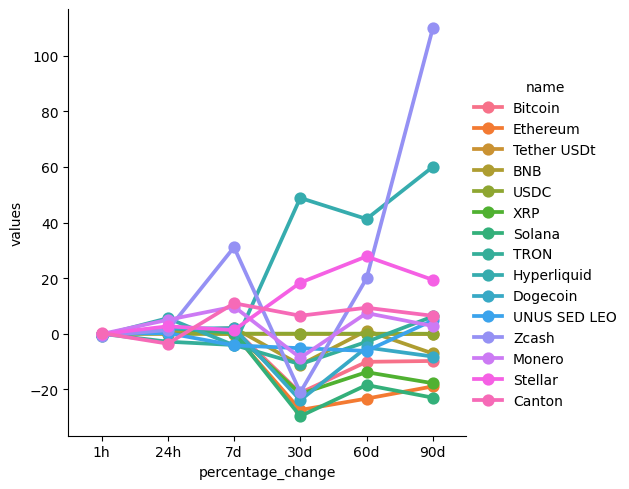

In [66]:
sns.catplot(x='percentage_change', y='values', hue='name', data=df7, kind='point')

In [92]:
df10 = df[['name','quote.USD.price', 'timestamp']]
df10 = df10.query("name == 'Bitcoin'")
df10

,name,quote.USD.price,timestamp
0,Bitcoin,63749.69283,2026-06-12 17:21:38.556153
15,Bitcoin,63750.00502,2026-06-12 17:22:40.577541
30,Bitcoin,63731.07794,2026-06-12 17:23:42.545078


<Axes: xlabel='timestamp', ylabel='quote.USD.price'>

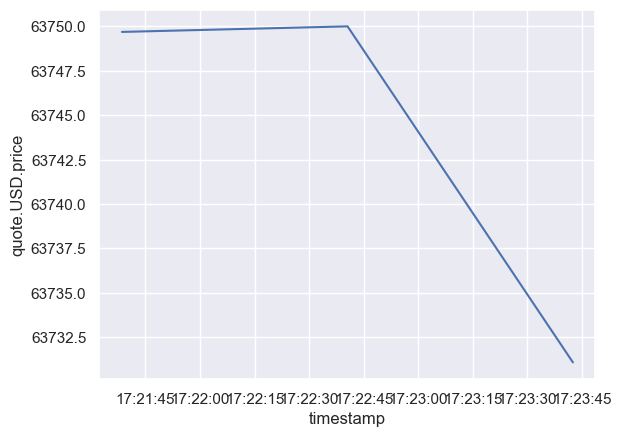

In [93]:
sns.set_theme(style='darkgrid')

sns.lineplot(x='timestamp', y = 'quote.USD.price', data= df10)